In [39]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPool2D, Flatten, Dense, BatchNormalization, Dropout, RandomRotation, RandomContrast
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import BinaryAccuracy, TruePositives,TrueNegatives,FalsePositives,FalseNegatives,AUC
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback,CSVLogger, LearningRateScheduler
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2
from tensorflow.keras.callbacks import Callback, EarlyStopping, LearningRateScheduler, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import sklearn
from sklearn.metrics import confusion_matrix,roc_curve
import seaborn as sns
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

## Data Preparation

### Data Loading

In [40]:
dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset",              # path to root folder
    labels="inferred",      # infer labels from subfolders
    label_mode="int",       # gives 0/1 for binary classification
    image_size=(100, 100),  # resize images
    shuffle=True,
    batch_size=None
)

class_names = dataset.class_names

Found 404 files belonging to 2 classes.


In [41]:
dataset

<ShuffleDataset element_spec=(TensorSpec(shape=(100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>

In [42]:
for images,labels in dataset.take(3):
    print("Image Data: ",images.numpy())
    print("Label Data: ",labels.numpy())
    print()

Image Data:  [[[ 53.        53.        53.      ]
  [ 48.        48.        48.      ]
  [ 46.5       46.5       46.5     ]
  ...
  [ 51.5       51.5       51.5     ]
  [ 52.625     52.625     52.625   ]
  [ 52.        52.        52.      ]]

 [[ 53.        53.        53.      ]
  [ 49.625     49.625     49.625   ]
  [ 50.928127  50.928127  50.928127]
  ...
  [ 52.353127  52.353127  52.353127]
  [ 53.84375   53.84375   53.84375 ]
  [ 53.625     53.625     53.625   ]]

 [[ 53.        53.        53.      ]
  [ 52.375     52.375     52.375   ]
  [ 58.421875  58.421875  58.421875]
  ...
  [ 53.796875  53.796875  53.796875]
  [ 55.90625   55.90625   55.90625 ]
  [ 56.375     56.375     56.375   ]]

 ...

 [[248.25     248.25     248.25    ]
  [248.95312  248.95312  248.95312 ]
  [250.73438  250.73438  250.73438 ]
  ...
  [254.       254.       254.      ]
  [254.       254.       254.      ]
  [254.       254.       254.      ]]

 [[249.35     249.35     249.35    ]
  [250.39688  250.39688 

In [43]:
DATASET_SIZE = len(dataset)
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

print(DATASET_SIZE)

404


In [44]:
def split_data(dataset,TRAIN_RATIO,VAL_RATIO,TEST_RATIO):
    DATASET_SIZE = len(dataset)

    train_dataset = dataset.take(int(TRAIN_RATIO * DATASET_SIZE))

    val_test_dataset = dataset.skip(int(TRAIN_RATIO * DATASET_SIZE))
    val_dataset = val_test_dataset.take(int(VAL_RATIO*DATASET_SIZE))

    test_dataset = val_test_dataset.skip(int(VAL_RATIO*DATASET_SIZE))

    return train_dataset,val_dataset,test_dataset
    

In [45]:
train_dataset,val_dataset,test_dataset = split_data(dataset,TRAIN_RATIO,VAL_RATIO,TEST_RATIO)
print(train_dataset)

#print(list(test_dataset.take(3).as_numpy_iterator()))  
for data in train_dataset.take(1):   #Data consist of both Image and Label data
    print(data)

<TakeDataset element_spec=(TensorSpec(shape=(100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>
(<tf.Tensor: shape=(100, 100, 3), dtype=float32, numpy=
array([[[60.      , 60.      , 60.      ],
        [59.915   , 59.915   , 59.915   ],
        [59.525   , 59.525   , 59.525   ],
        ...,
        [74.425   , 74.425   , 74.425   ],
        [73.255005, 73.255005, 73.255005],
        [73.      , 73.      , 73.      ]],

       [[60.1     , 60.1     , 60.1     ],
        [60.0133  , 60.0133  , 60.0133  ],
        [59.6155  , 59.6155  , 59.6155  ],
        ...,
        [74.39975 , 74.39975 , 74.39975 ],
        [73.22585 , 73.22585 , 73.22585 ],
        [72.97    , 72.97    , 72.97    ]],

       [[63.5     , 63.5     , 63.5     ],
        [63.355503, 63.355503, 63.355503],
        [62.6925  , 62.6925  , 62.6925  ],
        ...,
        [73.54125 , 73.54125 , 73.54125 ],
        [72.23476 , 72.23476 , 72.23476 ],
        [71.95    , 71.95    , 

### Data Visualization

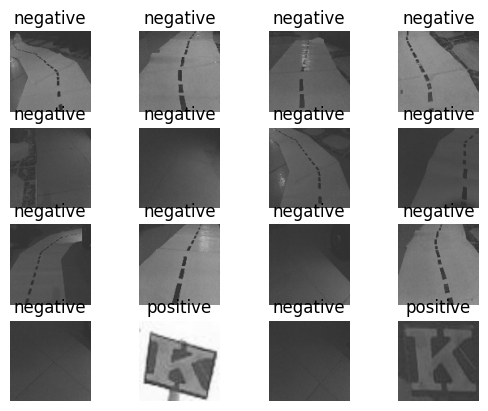

In [46]:
for i, (image,label) in enumerate(train_dataset.take(16)):
    ax = plt.subplot(4,4,i+1)
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(class_names[label])
    plt.axis('off')

### Data Preprocessing

In [47]:
#A function that Normalize data
IMG_SIZE = 100
def image_normalized(image,label):
    return image/255.0,label

#### Data Augmentation

In [48]:
# Data Augmentation
def visualize(original, augmented):
    plt.subplot(1,2,1)
    plt.imshow(original)

    plt.subplot(1,2,2)
    plt.imshow(augmented)

In [49]:
#Visualize Augmented Image
original_image, label = next(iter(train_dataset))
random_brightness_layer = tf.keras.layers.RandomContrast(factor = (0.9,1.15))
image_with_batch_dim = tf.expand_dims(original_image, axis=0)
augmented_batch = random_brightness_layer(image_with_batch_dim, training=True)
augmented_image = augmented_batch[0]
# visualize(original_image, augmented_image)

In [50]:
#Keras data augmentation
augment_layers = tf.keras.Sequential([
    
    RandomRotation(factor = (0.031,0.041)),
    RandomContrast(factor = (0.9,1.15))    
])

def augment_layer(image,label):
    image,label = image_normalized(image, label)
    return augment_layers(image,training=True),label

#### Data Loading

In [51]:
#Shuffle, Batch and Allow for prefetch of Train_dataset
BATCH_SIZE = 8
train_dataset = (train_dataset
    .shuffle(buffer_size=8,reshuffle_each_iteration=True)
    .map(augment_layer)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
    )

print(train_dataset)

<PrefetchDataset element_spec=(TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [52]:
val_dataset = val_dataset.shuffle(buffer_size=8,reshuffle_each_iteration=True).map(image_normalized).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(val_dataset)

<PrefetchDataset element_spec=(TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [53]:
#Normalize test_dataset
test_dataset = test_dataset.map(image_normalized) 
print(test_dataset)

<MapDataset element_spec=(TensorSpec(shape=(100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>


## Model Creation and Training

### Sequential API

In [54]:
#Classifier Model
dropout_rate = 0.2
regularization_rate = 0.01
model = tf.keras.Sequential([InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)), #Specifies the shape input data shape

                             #Feature Extraction Layer
                             Conv2D(filters = 6, kernel_size = 3, strides = 1, padding='valid', activation='relu', kernel_regularizer= l2(regularization_rate)),      #ConvNet layer with 6 outputs(neurons)- each contains the kernel and bias
                             BatchNormalization(),
                             MaxPool2D(pool_size = 2,strides = 2),    #max pooling layer - selects the maximum value from each kernel window
                             Dropout(dropout_rate),

                             Conv2D(filters = 10, kernel_size = 3, strides = 1, padding='valid', activation='relu', kernel_regularizer= l2(regularization_rate)),      #ConvNet layer
                             BatchNormalization(),
                             MaxPool2D(pool_size = 2,strides = 2),    #max pooling layer
                             Dropout(dropout_rate),

                             
                             Flatten(), #flatten layer - converts 2D feature to 1D vector

                             #Classification Layer
                             Dense(15, activation = 'relu', kernel_regularizer= l2(regularization_rate)),      #dense layer with 10 neurons
                             Dropout(dropout_rate),
                             
                             Dense(1, activation = 'sigmoid'),      #Output layer (for 2-class classification)
])   
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 98, 98, 6)         168       
                                                                 
 batch_normalization_6 (Batc  (None, 98, 98, 6)        24        
 hNormalization)                                                 
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 49, 49, 6)        0         
 2D)                                                             
                                                                 
 dropout_9 (Dropout)         (None, 49, 49, 6)         0         
                                                                 
 conv2d_7 (Conv2D)           (None, 47, 47, 10)        550       
                                                                 
 batch_normalization_7 (Batc  (None, 47, 47, 10)      

### EarlyStoppage

In [55]:
#Early Stoppage
es_callback = EarlyStopping(
    monitor='val_loss', min_delta=0, patience=2, verbose=1,
    mode='auto', baseline=None, restore_best_weights=False
)

### LearningRateScheduler

In [56]:
def scheduler(epoch, lr):

  if epoch <= 1:
    return lr
  else:
    return  lr * tf.math.exp(-0.1)

scheduler_callback = LearningRateScheduler(scheduler, verbose = 1)

### ReduceLearningRateOnPlateau

In [57]:
plateau_callback = ReduceLROnPlateau(
    monitor='val_accuracy', factor=0.1, patience=5, verbose=1
)
   

### Model Training

In [58]:
# Error Sanctioning
model.compile(optimizer=Adam(learning_rate=0.01), 
              loss=BinaryCrossentropy(), 
              metrics='accuracy'
             )

In [59]:
#Training of the model
with tf.device('GPU:0'):
    #model_history = model.fit(train_dataset,validation_data=val_dataset,epochs = 25, verbose = 1)
    model_history = model.fit(train_dataset,validation_data=val_dataset,epochs = 25, verbose = 1, callbacks = [es_callback,scheduler_callback,plateau_callback])


Epoch 1: LearningRateScheduler setting learning rate to 0.009999999776482582.
Epoch 1/25
41/41 [==============================] - 4s 44ms/step - loss: 5.3411 - accuracy: 0.8235 - val_loss: 3.0504 - val_accuracy: 0.9000 - lr: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.009999999776482582.
Epoch 2/25
41/41 [==============================] - 2s 35ms/step - loss: 3.2760 - accuracy: 0.9288 - val_loss: 5.3101 - val_accuracy: 0.7500 - lr: 0.0100

Epoch 3: LearningRateScheduler setting learning rate to 0.009048373438417912.
Epoch 3/25
41/41 [==============================] - 1s 31ms/step - loss: 2.9709 - accuracy: 0.9381 - val_loss: 2.0750 - val_accuracy: 0.9000 - lr: 0.0090

Epoch 4: LearningRateScheduler setting learning rate to 0.008187306113541126.
Epoch 4/25
41/41 [==============================] - 1s 29ms/step - loss: 1.8944 - accuracy: 0.9443 - val_loss: 4.7964 - val_accuracy: 0.7500 - lr: 0.0082

Epoch 5: LearningRateScheduler setting learning rate to 0.007408180

### Visualization of Training Result

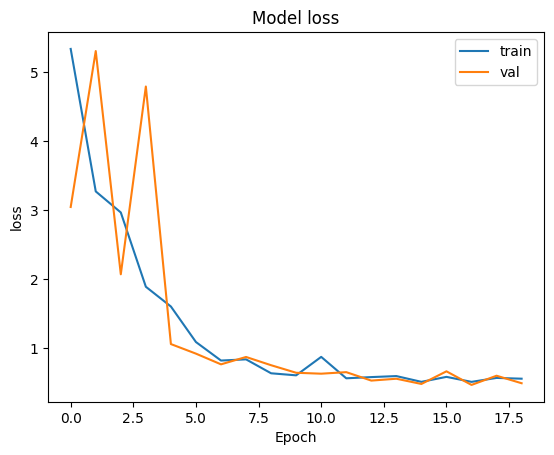

In [60]:
# Plotting of Result
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['train','val'])
plt.show()

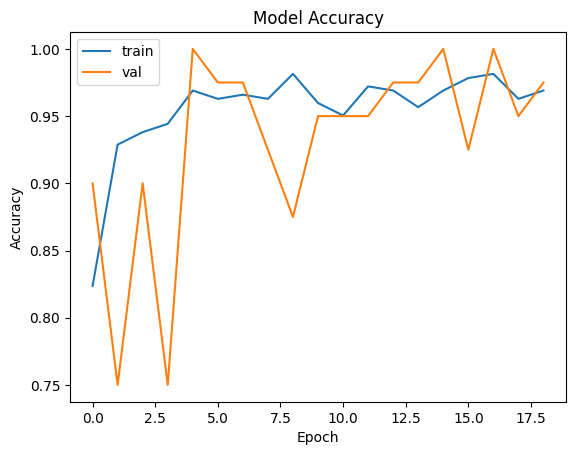

In [61]:
# Plotting of Result
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train','val'])
plt.show()

## Model Evaluation and Testing

In [62]:
test_dataset = test_dataset.batch(1)  #make shape compatible with train_dataset
print(test_dataset)

<BatchDataset element_spec=(TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [63]:
model.evaluate(test_dataset)

41/41 [==============================] - 0s 6ms/step - loss: 0.5474 - accuracy: 0.9512


[0.5474228262901306, 0.9512194991111755]

### Visualizing Confusion Matrix

In [64]:
labels = []
inp = []

for x,y in test_dataset.as_numpy_iterator():
  labels.append(y)
  inp.append(x)

In [65]:
print(np.array(inp).shape)
print(np.array(inp)[:,0,...].shape)

(41, 1, 100, 100, 3)
(41, 100, 100, 3)


In [66]:
labels = np.array([i[0] for i in labels])
print(labels)

[0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0]


In [67]:
predicted = model.predict(np.array(inp)[:,0,...])
print(predicted[:,0])

2/2 [==============================] - 0s 11ms/step
[2.65546812e-04 6.69694145e-07 7.72620545e-09 1.64856378e-03
 2.94697020e-05 9.92151380e-01 9.25474069e-06 9.79010940e-01
 3.16194701e-03 2.47450080e-03 1.00000000e+00 5.02145410e-01
 2.09980257e-07 7.05218852e-01 5.67799834e-05 3.09717620e-06
 3.06625614e-10 1.57352854e-02 2.01194916e-06 1.50864027e-04
 4.92583308e-03 3.88848057e-05 6.80877641e-03 8.48768726e-02
 4.78875451e-03 1.12076394e-01 1.00000000e+00 3.30291991e-03
 5.19739697e-04 1.16513820e-05 5.48814303e-13 3.89829074e-06
 3.17785707e-05 1.01124507e-03 7.63181690e-03 3.89194574e-05
 2.80725581e-05 3.22271176e-02 1.76973944e-03 1.00083758e-04
 5.13228349e-09]


[[35  1]
 [ 0  5]]


Text(0.5, 58.7222222222222, 'Predicted')

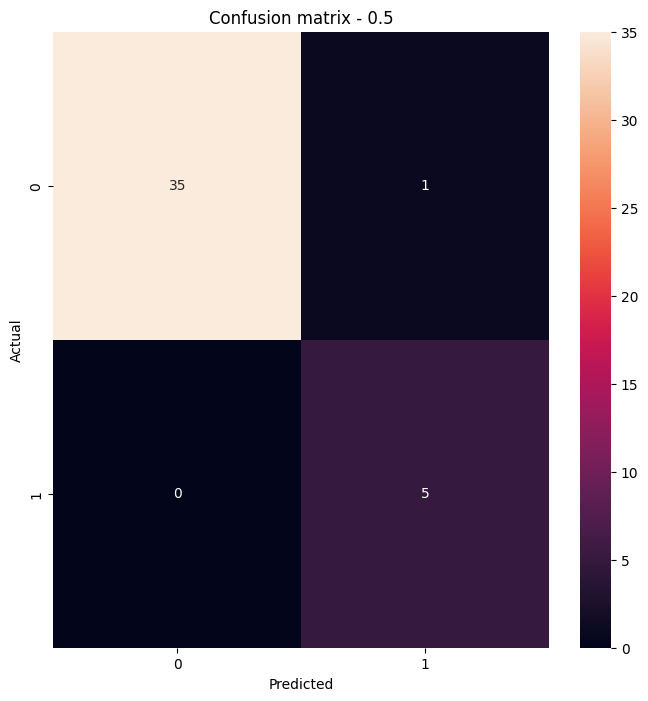

In [68]:
threshold = 0.5

cm = confusion_matrix(labels, predicted > threshold)
print(cm)
plt.figure(figsize=(8,8))

sns.heatmap(cm, annot=True,)
plt.title('Confusion matrix - {}'.format(threshold))
plt.ylabel('Actual')
plt.xlabel('Predicted')

### ROC Plots

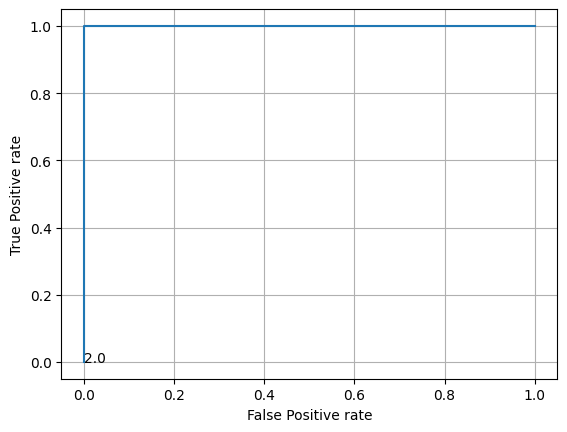

In [69]:
fp, tp, thresholds = roc_curve(labels, predicted)
plt.plot(fp, tp)
plt.xlabel("False Positive rate")
plt.ylabel("True Positive rate")

plt.grid()

skip = 20

for i in range(0, len(thresholds), skip):
  plt.text(fp[i], tp[i], thresholds[i])
  
plt.show()

### Prediction

In [70]:
def sign_or_not(x):
    if(x<0.5):
        return str('N')
    else:
        return str('P')

In [71]:
sign_or_not(model.predict(test_dataset.take(1))[0][0])


1/1 [==============================] - 0s 378ms/step


'N'

1/1 [==============================] - 0s 43ms/step


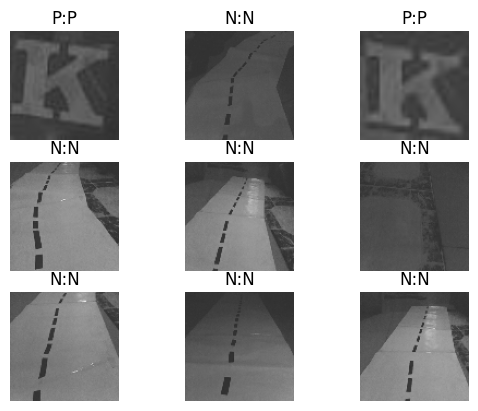

In [72]:
for i, (image,label) in enumerate(test_dataset.take(9)):

    ax = plt.subplot(3,3,i+1)
    plt.imshow(image[0])
    plt.title(str(sign_or_not(label.numpy()[0])) + ":"+str(sign_or_not(model.predict(image)[0][0])))

    plt.axis('off')

## Saving Model

In [73]:
#Save Model
model.save("symbol_detection_model")


INFO:tensorflow:Assets written to: symbol_detection_model\assets


INFO:tensorflow:Assets written to: symbol_detection_model\assets


In [74]:
# Load  saved model
model = tf.keras.models.load_model("symbol_detection_model")

# Convert to concrete function
full_model = tf.function(lambda x: model(x))
full_model = full_model.get_concrete_function(
    tf.TensorSpec(model.inputs[0].shape, model.inputs[0].dtype))

# Convert to frozen graph
frozen_func = convert_variables_to_constants_v2(full_model)
frozen_func.graph.as_graph_def()

# Save frozen graph
tf.io.write_graph(frozen_func.graph, ".", "symbol_detector.pb", as_text=False)

'.\\symbol_detector.pb'